In [31]:
import sys
print(sys.executable)

import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy

/Users/amywang/JHU/Research/golfanalytics/.venv/bin/python


In [2]:
df = pd.read_csv('GGXY.csv')

#remove rows without data
df.replace('-',np.nan,inplace=True)
df.dropna(inplace=True)

X = df.drop(['Club','Carry'],axis=1).astype(float) #only keep key metrics
y = df['Carry'].astype(float)

### Random Forest

            Feature  Importance
1        Ball Speed    0.413986
0        Club Speed    0.395332
2      Launch Angle    0.109315
3         Spin Rate    0.059039
7      Attack Angle    0.006370
5      Face to Path    0.004680
4        Face Angle    0.004539
6         Club Path    0.003790
8  Launch Direction    0.002949


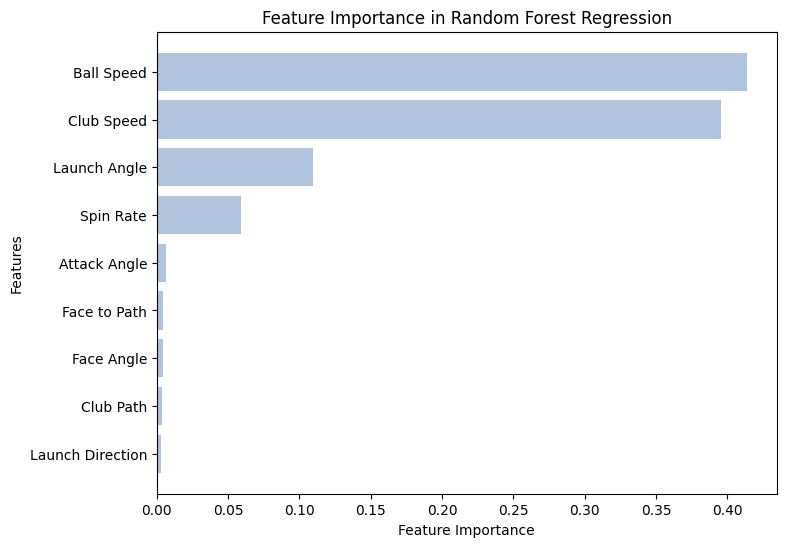

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

#train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=500)

#standard random forest regressor
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

#importances
feature_importances = pd.DataFrame({'Feature': X.columns,'Importance': rf_model.feature_importances_}).sort_values(by='Importance', ascending=False)
print(feature_importances)

plt.figure(figsize=(8, 6))
plt.barh(feature_importances['Feature'], feature_importances['Importance'], color='lightsteelblue')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance in Random Forest Regression')
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.show()

### SVR

R-squared for Club Speed: 0.76359
Optimal X ranges for maximizing Y on Club Speed (limited to 2): [(np.float64(100.0122244488978), np.float64(105.69719438877755))]


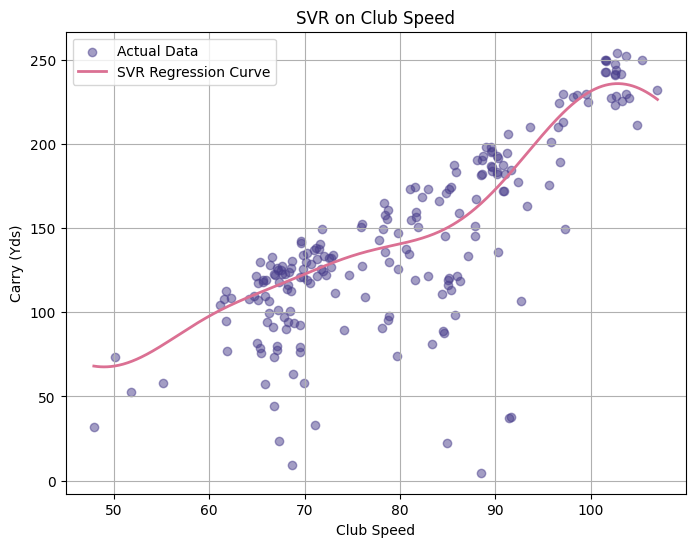

R-squared for Ball Speed: 0.92968
Optimal X ranges for maximizing Y on Ball Speed (limited to 2): [(np.float64(153.56072144288578), np.float64(153.81563126252505)), (np.float64(154.07054108216434), np.float64(154.58036072144287))]


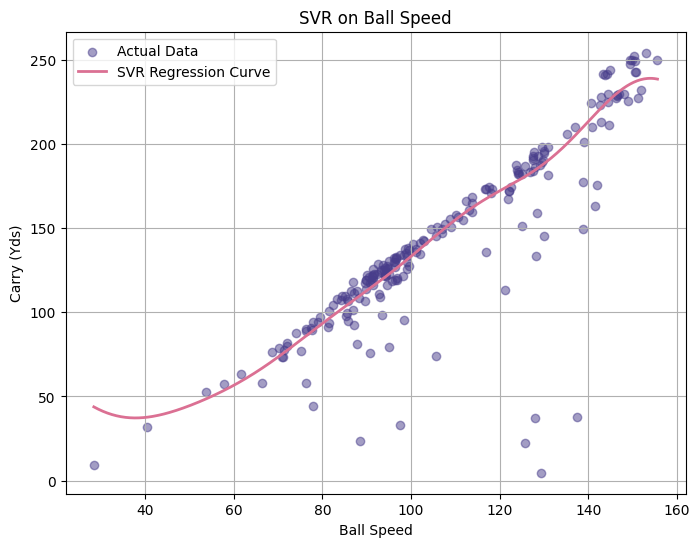

R-squared for Launch Angle: 0.10881
Optimal X ranges for maximizing Y on Launch Angle (limited to 2): [(np.float64(11.999398797595193), np.float64(12.082965931863729)), (np.float64(12.166533066132267), np.float64(12.250100200400803))]


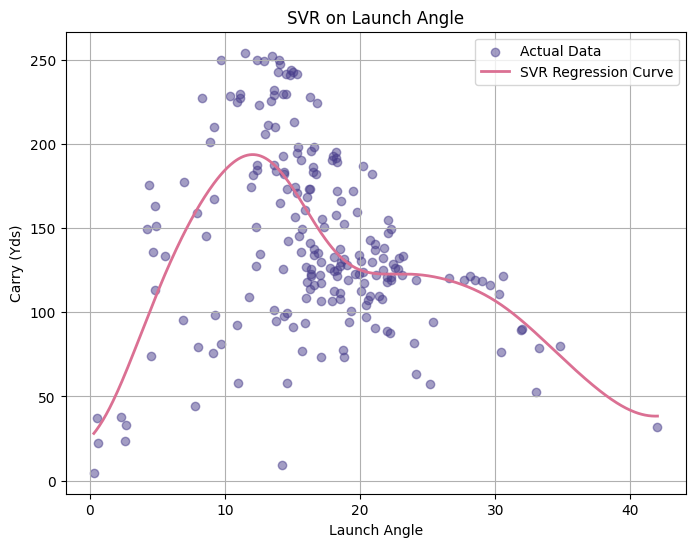

R-squared for Spin Rate: 0.01424
Optimal X ranges for maximizing Y on Spin Rate (limited to 2): [(np.float64(5015.054108216433), np.float64(5015.054108216433)), (np.float64(5036.316633266533), np.float64(5036.316633266533))]


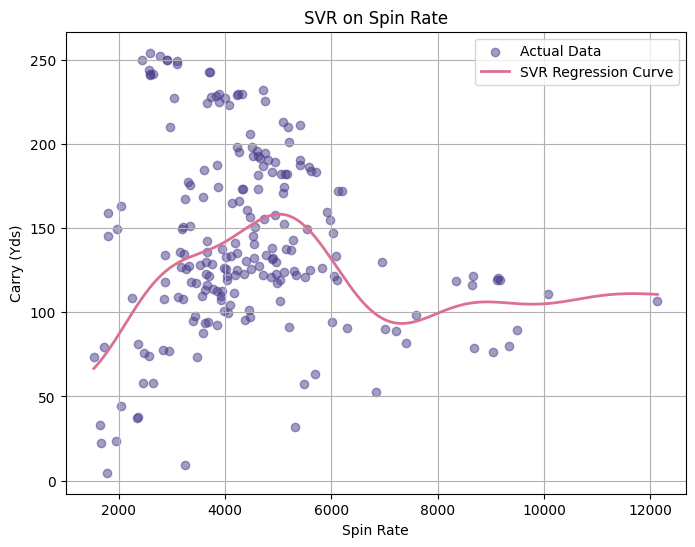

R-squared for Face Angle: 0.02175
Optimal X ranges for maximizing Y on Face Angle (limited to 2): [(np.float64(-3.08637274549098), np.float64(-2.6378757515030067)), (np.float64(-3.7591182364729434), np.float64(-3.161122244488979))]


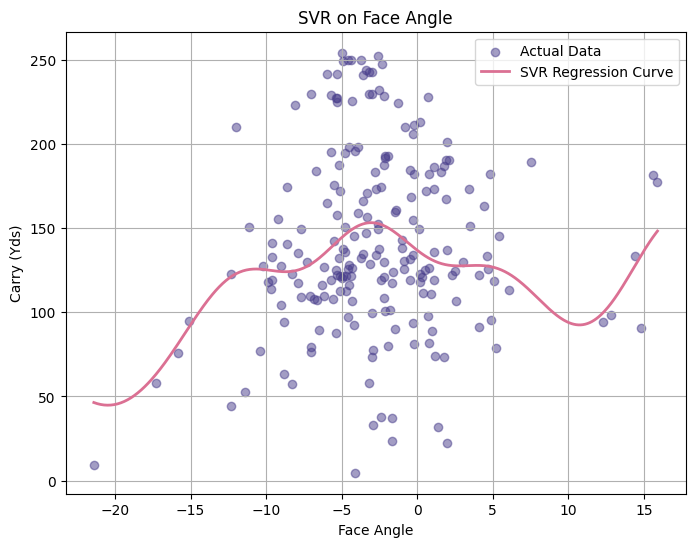

R-squared for Face to Path: 0.15649
Optimal X ranges for maximizing Y on Face to Path (limited to 2): [(np.float64(0.0430861723446867), np.float64(2.5689378757515016))]


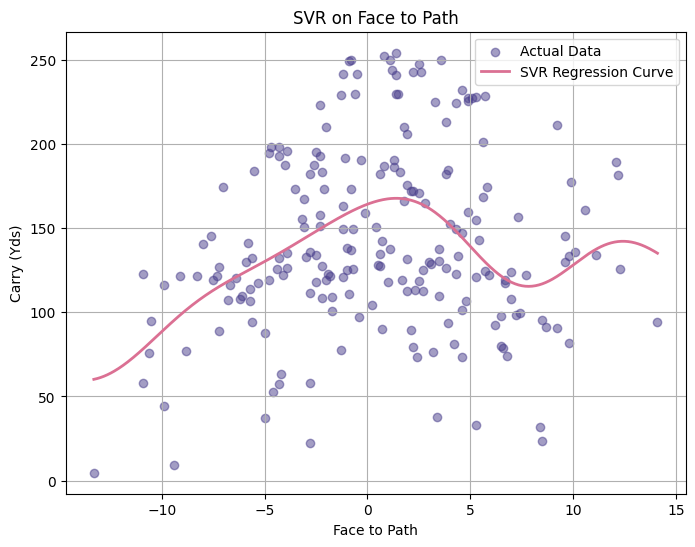

R-squared for Club Path: -0.06943
Optimal X ranges for maximizing Y on Club Path (limited to 2): [(np.float64(-6.14869739478958), np.float64(-6.102605210420843)), (np.float64(-6.056513026052105), np.float64(-6.010420841683368))]


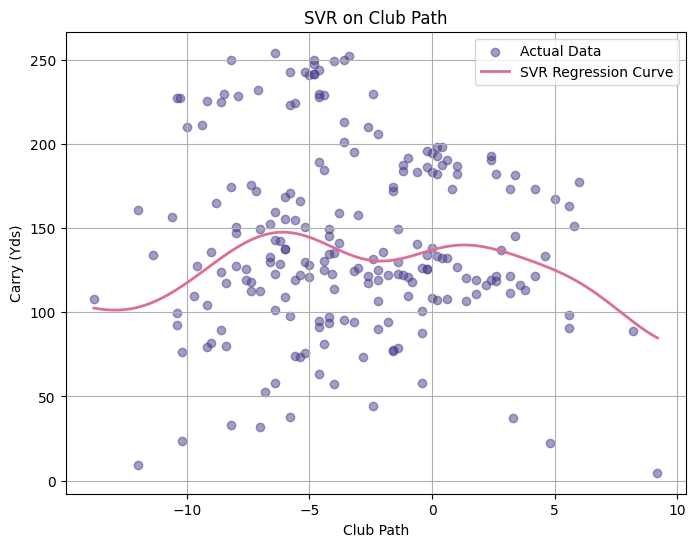

R-squared for Attack Angle: 0.09399
Optimal X ranges for maximizing Y on Attack Angle (limited to 2): [(np.float64(-1.9639278557114235), np.float64(-0.7102204408817636))]


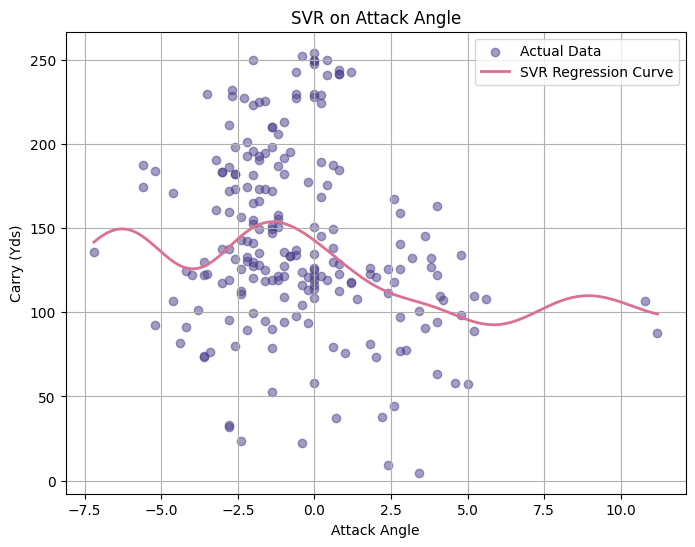

R-squared for Launch Direction: 0.01904
Optimal X ranges for maximizing Y on Launch Direction (limited to 2): [(np.float64(14.1), np.float64(14.1)), (np.float64(13.914829659318634), np.float64(14.038276553106208))]


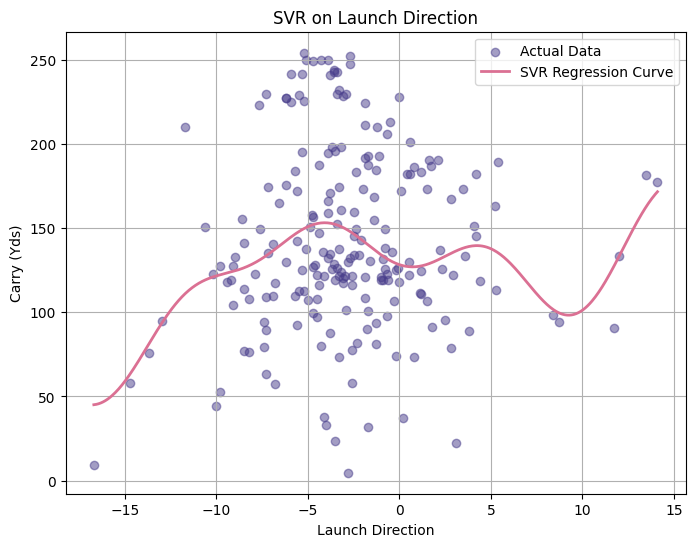

In [48]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

r2scores = []
optimal_ranges = []

for i in range(9):
    X_feature = X[X.columns[i]].to_numpy().reshape(-1,1)
    X_train, X_test, y_train, y_test = train_test_split(X_feature, y, test_size=0.2, random_state=500)
    
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
    
    svr = SVR(kernel='rbf')
    svr.fit(X_train_scaled, y_train_scaled) 
    
    regression_lines[i].append(svr._dual_coef_[0])

    y_pred_scaled = svr.predict(X_test_scaled)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()
    
    X_range = np.linspace(X_feature.min(), X_feature.max(), 500).reshape(-1, 1)
    X_range_scaled = scaler_X.transform(X_range)
    
    y_range_pred_scaled = svr.predict(X_range_scaled)
    y_range_pred = scaler_y.inverse_transform(y_range_pred_scaled.reshape(-1, 1)).ravel()
    
    r2 = r2_score(y_test,y_pred)
    r2scores.append(r2)
    print(f'R-squared for {X.columns[i]}: {r2:.5f}')
    
   # Identify the optimal X range that maximizes Y
    max_y = np.max(y_range_pred)  # Maximum Y value
    threshold = 0.98 * max_y  # Define threshold for "near max" regions
    
    optimal_x_values = X_range[y_range_pred >= threshold].flatten()
    
    # Find continuous ranges
    discrete_ranges = []
    start = optimal_x_values[0]
    
    for j in range(1, len(optimal_x_values)):
        if optimal_x_values[j] - optimal_x_values[j-1] > (X_range[1] - X_range[0]):
            discrete_ranges.append((start, optimal_x_values[j-1]))  # Save the previous range
            start = optimal_x_values[j]  # Start new range
    discrete_ranges.append((start, optimal_x_values[-1]))  # Add last range

    # Limit to at most 2 optimal ranges by sorting based on the average predicted Y value in each range
    discrete_ranges = sorted(discrete_ranges, key=lambda r: np.mean(y_range_pred[(X_range.flatten() >= r[0]) & (X_range.flatten() <= r[1])]), reverse=True)[:2]

    optimal_ranges.append((X.columns[i], discrete_ranges))

    print(f"Optimal X ranges for maximizing Y on {X.columns[i]} (limited to 2): {discrete_ranges}")
    
    plt.figure(figsize=(8, 6))
    plt.scatter(X_feature, y, color='darkslateblue', alpha=0.5, label='Actual Data')
    plt.plot(X_range, y_range_pred, color='palevioletred', lw=2, label='SVR Regression Curve')
    plt.xlabel(X.columns[i])
    plt.ylabel('Carry (Yds)')
    plt.title(f'SVR on {X.columns[i]}')
    plt.legend()
    plt.grid(True)
    plt.show()

### Finding Optimal Ranges

In [51]:
ranges_df = pd.DataFrame(optimal_ranges)
display(ranges_df.transpose())

,0,1,2,3,4,5,6,7,8
0,Club Speed,Ball Speed,Launch Angle,Spin Rate,Face Angle,Face to Path,Club Path,Attack Angle,Launch Direction
1,"[(100.0122244488978, 105.69719438877755)]","[(153.56072144288578, 153.81563126252505), (15...","[(11.999398797595193, 12.082965931863729), (12...","[(5015.054108216433, 5015.054108216433), (5036...","[(-3.08637274549098, -2.6378757515030067), (-3...","[(0.0430861723446867, 2.5689378757515016)]","[(-6.14869739478958, -6.102605210420843), (-6....","[(-1.9639278557114235, -0.7102204408817636)]","[(14.1, 14.1), (13.914829659318634, 14.0382765..."


### R-Squared

            Feature  R-squared
1        Ball Speed   0.929681
0        Club Speed   0.763593
5      Face to Path   0.156485
2      Launch Angle   0.108808
7      Attack Angle   0.093988
4        Face Angle   0.021751
8  Launch Direction   0.019040
3         Spin Rate   0.014243
6         Club Path  -0.069434


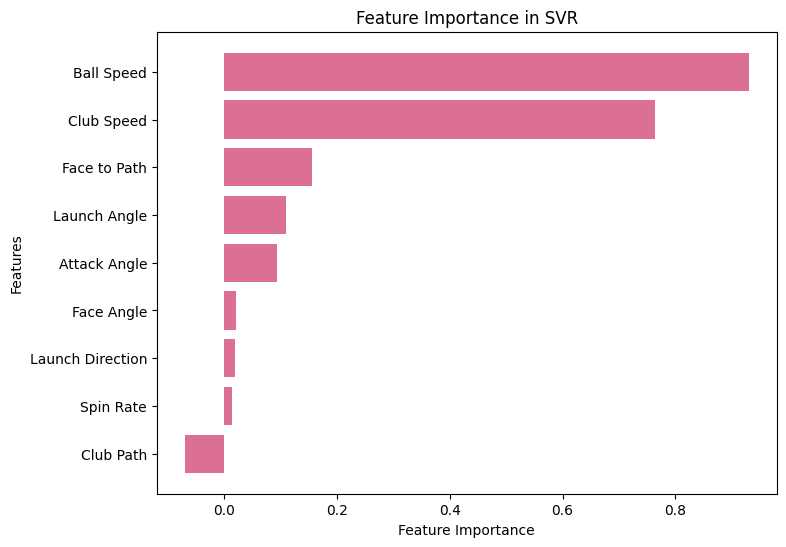

In [5]:
scores = pd.DataFrame({'Feature': X.columns,'R-squared': r2scores}).sort_values(by='R-squared', ascending=False)
print(scores)

plt.figure(figsize=(8, 6))
plt.barh(scores['Feature'], scores['R-squared'], color='palevioletred')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance in SVR')
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.show()

### Heat maps

In [ ]:
def create_heatmap(x, y, z, xlabel, ylabel, title):
    x = x.apply(pd.to_numeric, errors='coerce')
    y = y.apply(pd.to_numeric, errors='coerce')
    z = z.apply(pd.to_numeric, errors='coerce')

    heatmap_data, xedges, yedges = np.histogram2d(x, y, bins=100, weights=z)
    counts, _, _ = np.histogram2d(x, y, bins=bins)
    heatmap_avg = np.divide(heatmap_data, counts, out=np.zeros_like(heatmap_data), where=counts != 0)

    heatmap_smooth = scipy.ndimage.gaussian_filter(heatmap_avg, sigma=1.5)

    plt.figure(figsize=(8, 6))
    plt.imshow(
        heatmap_smooth.T, origin='lower', aspect='auto',
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        cmap='viridis', interpolation="bilinear"
    )
    plt.colorbar(label='Carry (yards)')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

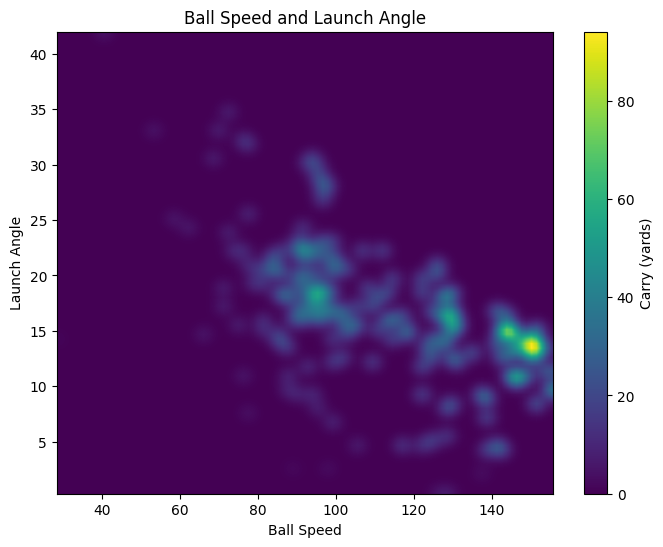

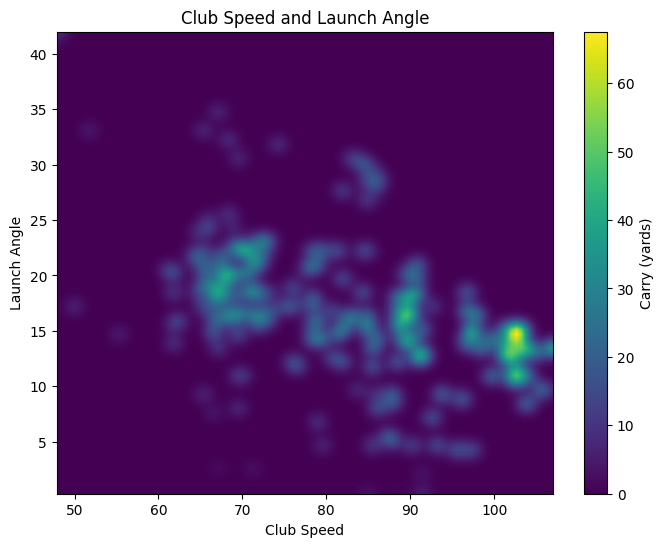

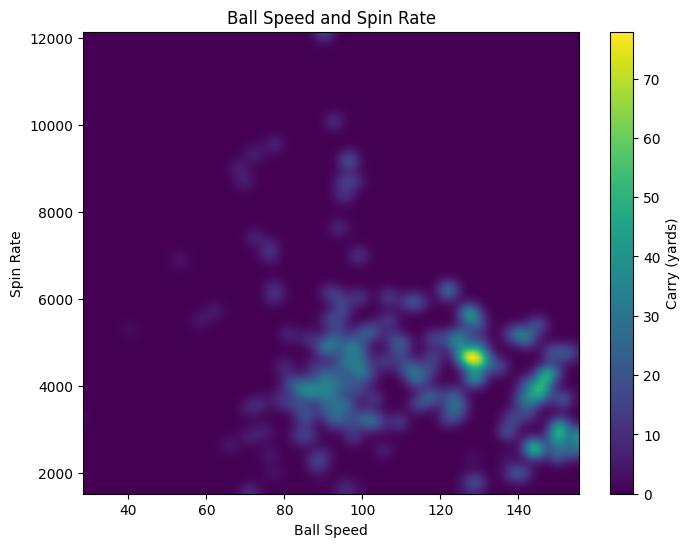

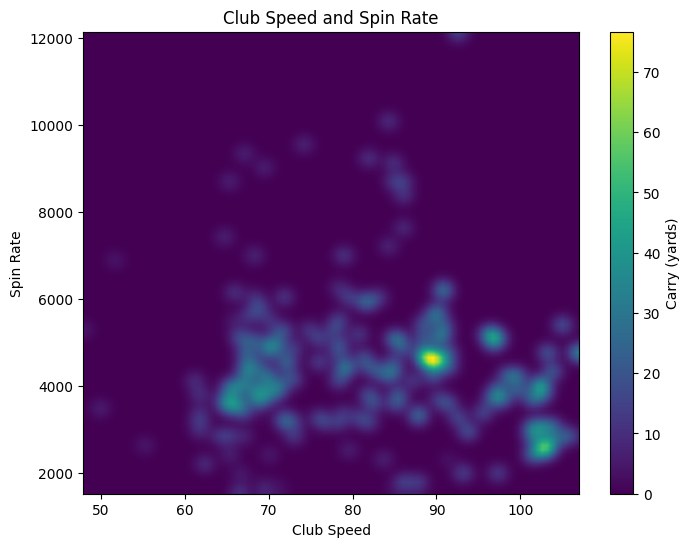

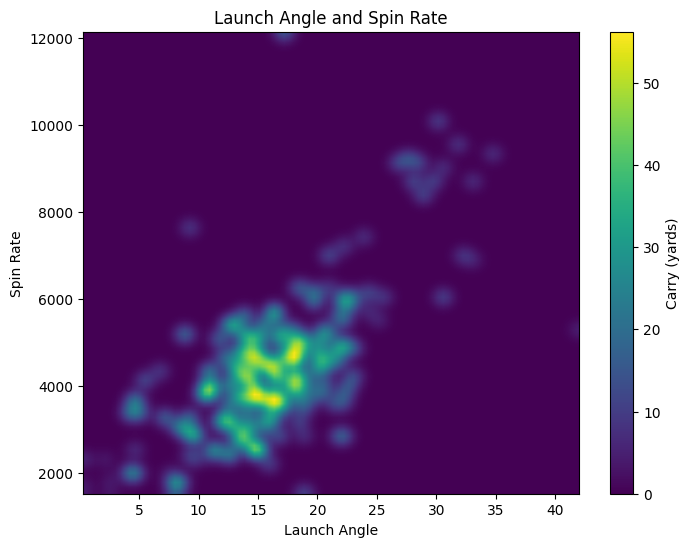

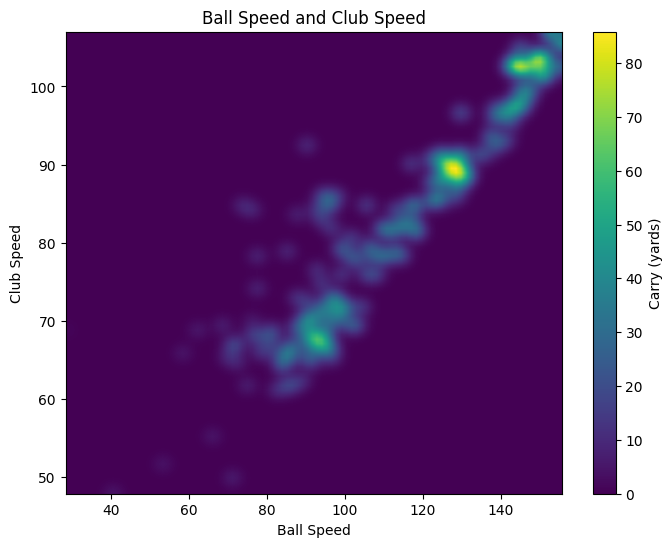

In [33]:
create_heatmap(df['Ball Speed'], df['Launch Angle'], df['Carry'], 'Ball Speed', 'Launch Angle', 'Ball Speed and Launch Angle')

create_heatmap(df['Club Speed'], df['Launch Angle'], df['Carry'], 'Club Speed', 'Launch Angle', 'Club Speed and Launch Angle')

create_heatmap(df['Ball Speed'], df['Spin Rate'], df['Carry'], 'Ball Speed', 'Spin Rate', 'Ball Speed and Spin Rate')

create_heatmap(df['Club Speed'], df['Spin Rate'], df['Carry'], 'Club Speed', 'Spin Rate', 'Club Speed and Spin Rate')

create_heatmap(df['Launch Angle'], df['Spin Rate'], df['Carry'], 'Launch Angle', 'Spin Rate', 'Launch Angle and Spin Rate')

create_heatmap(df['Ball Speed'], df['Club Speed'], df['Carry'], 'Ball Speed', 'Club Speed', 'Ball Speed and Club Speed')

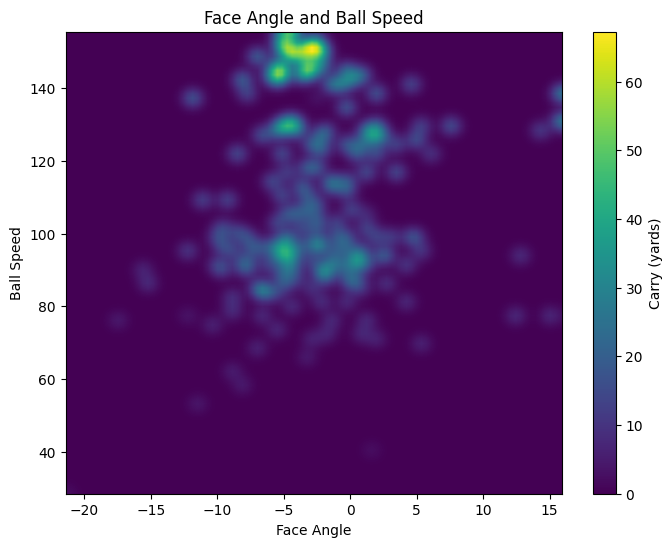

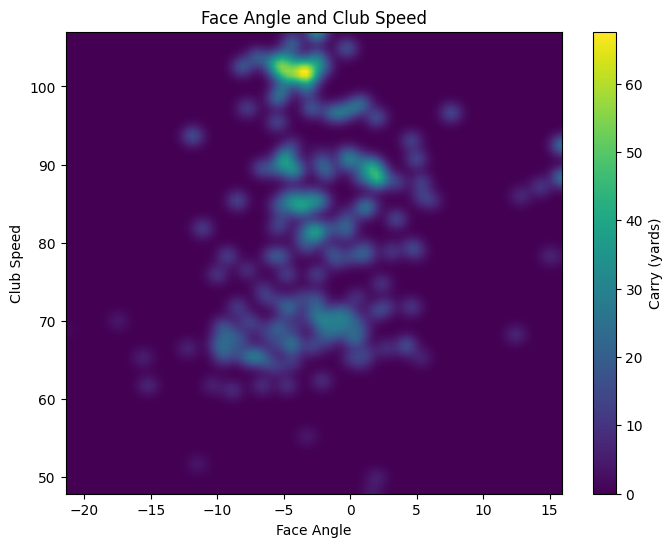

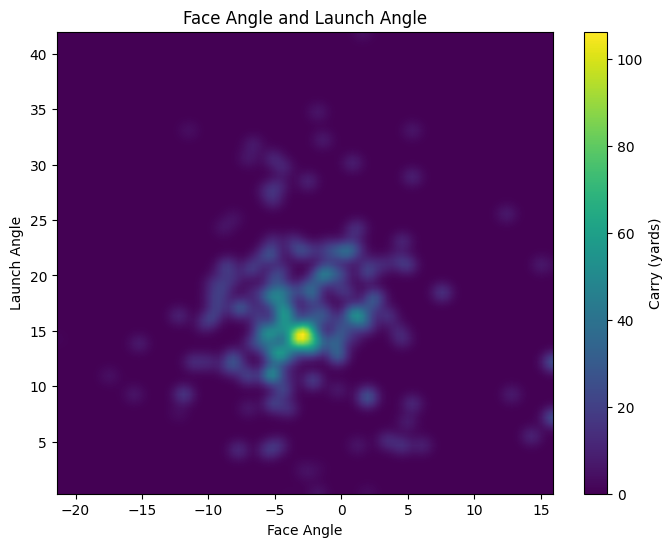

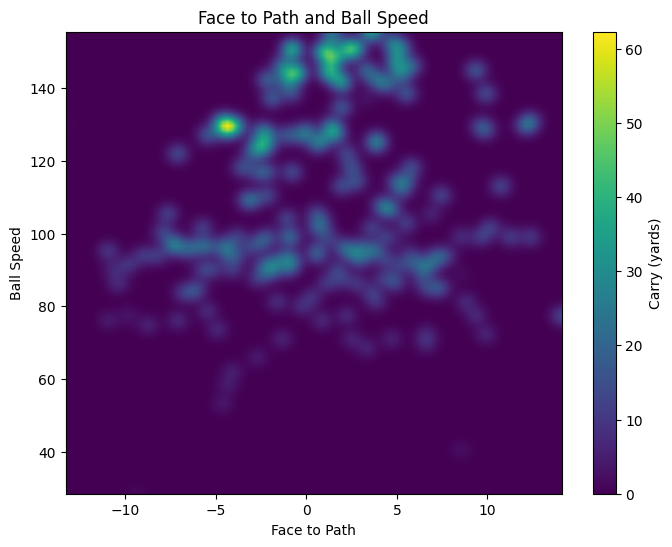

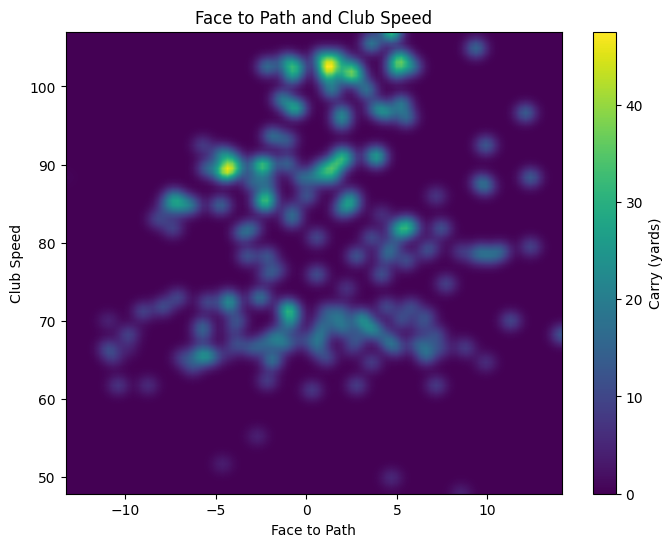

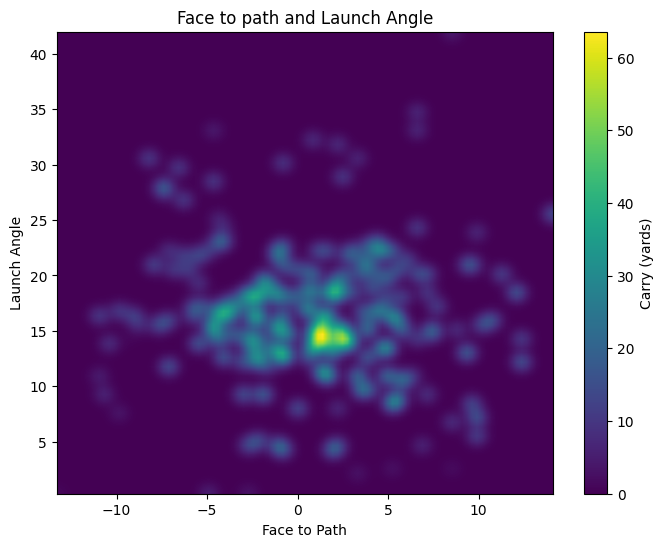

In [34]:
create_heatmap(df['Face Angle'], df['Ball Speed'], df['Carry'], 'Face Angle', 'Ball Speed', 'Face Angle and Ball Speed')

create_heatmap(df['Face Angle'], df['Club Speed'], df['Carry'], 'Face Angle', 'Club Speed', 'Face Angle and Club Speed')

create_heatmap(df['Face Angle'], df['Launch Angle'], df['Carry'], 'Face Angle', 'Launch Angle', 'Face Angle and Launch Angle')

create_heatmap(df['Face to Path'], df['Ball Speed'], df['Carry'], 'Face to Path', 'Ball Speed', 'Face to Path and Ball Speed')

create_heatmap(df['Face to Path'], df['Club Speed'], df['Carry'], 'Face to Path', 'Club Speed', 'Face to Path and Club Speed')

create_heatmap(df['Face to Path'], df['Launch Angle'], df['Carry'], 'Face to Path', 'Launch Angle', 'Face to path and Launch Angle')

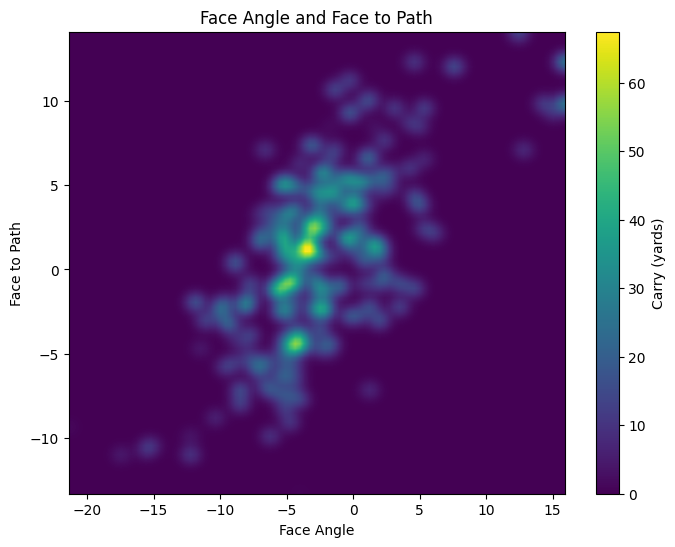

In [35]:
create_heatmap(df['Face Angle'], df['Face to Path'], df['Carry'], 'Face Angle', 'Face to Path', 'Face Angle and Face to Path')

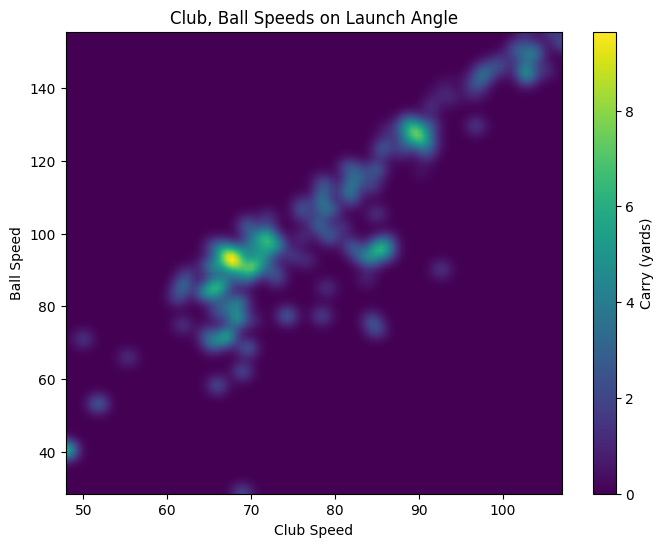

In [36]:
create_heatmap(df['Club Speed'], df['Ball Speed'], df['Launch Angle'], 'Club Speed', 'Ball Speed', 'Club, Ball Speeds on Launch Angle')

In [37]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset (assuming df is already preprocessed)
X = df.drop(['Club', 'Carry'], axis=1).astype(float)
y = df['Carry'].astype(float)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=500)

# Initialize XGBoost Regressor with similar parameters to RandomForestRegressor
xgb_model = xgb.XGBRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=6, 
    random_state=42
)

# Train the model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")

# Feature importance
feature_importances = pd.DataFrame({
    'Feature': X.columns, 
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importances)

# Plot feature importances
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.barh(feature_importances['Feature'], feature_importances['Importance'], color='lightsteelblue')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance in XGBoost Regression')
plt.gca().invert_yaxis()
plt.show()

XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/amywang/JHU/Research/golfanalytics/.venv/lib/python3.9/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <89AD948E-E564-3266-867D-7AF89D6488F0> /Users/amywang/JHU/Research/golfanalytics/.venv/lib/python3.9/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/ho